# Buy Now Pay Later: A Credit Risk Analysis
## Identifying Default Risk and Financial Vulnerability

---

### Introduction

Buy Now Pay Later (BNPL) allows users to 
split purchases into interest-free 
instalments. For financially informed users, 
it offers a genuine tool for managing cash 
flow without incurring interest.

However, the reality is more complicated.

A pilot study by the Financial Consumer 
Agency of Canada (FCAC, 2021) found that 
39% of Canadian BNPL users adopted the 
service because they could not afford the 
full purchase upfront. More concerningly, 
15% of users who repaid on time still made 
unfavourable financial trade-offs, including 
delaying other bills, overdrafting accounts, 
or cutting back on essentials.

Research from Payments Canada (2022) found 
that Canadians aged 18-34 are the highest 
adopters of BNPL. The Varsity (2026) 
specifically warns that students are 
particularly vulnerable to its financial 
risks. CTV News further highlights concerns 
around tracking multiple obligations and 
product design that encourages overspending.

These findings raise a key question: if 
successful repayment can still mask financial 
stress, what truly distinguishes a BNPL 
defaulter from someone who manages 
successfully?

---


### Research Question

"BNPL promises financial empowerment through 
flexible instalment payments. However, not 
all users benefit equally. This analysis 
investigates what distinguishes customers 
who successfully leverage BNPL from those 
who default, exploring whether BNPL fulfils 
its promise or disproportionately burdens 
vulnerable users."


---

### Dataset

This analysis uses a synthetic dataset of 
10,345 BNPL transactions across 6 countries 
including Canada (2023-2024), containing 
demographic, financial and behavioural 
features alongside a binary default 
indicator (default_flag).

In [1]:
# Library Imports

# Core libraries
import pandas as pd
import numpy as np
import sqlite3

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', 
              lambda x: '%.2f' % x)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('RdYlGn_r')

# Install kagglehub
!pip install kagglehub

  Using cached kagglehub-1.0.1-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.23-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.1-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.23-py3-none-any.whl (217 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


In [2]:
# Load Dataset

import kagglehub
import os
import pandas as pd
import sqlite3

# Download dataset from Kaggle
path = kagglehub.dataset_download(
    "shree0910/buy-now-and-pay-later-fintech-ml-dataset"
)

# Load CSV into pandas
csv_path = os.path.join(path, 
    'Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')

df = pd.read_csv(csv_path)

# Create SQLite database connection
conn = sqlite3.connect('bnpl.db')

# Load dataframe into SQLite
df.to_sql('bnpl_data', conn, 
          if_exists='replace', 
          index=False)

# Confirm successful load
print("Dataset loaded successfully")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())


Dataset loaded successfully
Rows: 10345
Columns: 17

Column names:
['user_id', 'age', 'employment_type', 'monthly_income', 'credit_score', 'purchase_amount', 'product_category', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'default_flag', 'app_usage_frequency', 'location', 'transaction_date', 'debt_to_income_ratio', 'risk_score', 'customer_segment']


## Data Overview

Before analysis, we examine the structure 
and quality of the dataset including data 
types, missing values, and basic descriptive 
statistics.


In [3]:
# Data Overview

# Data types and non-null counts
print(df.info())

# First few rows
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score         

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.07,165.20,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.15,266.00,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.12,229.60,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.28,356.00,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.12,135.20,High Risk


In [4]:
# Descriptive statistics
df.describe()

,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.00,10345.00,10345.00,10345.00,10345.00,10345.00,10345.00,10345.00,10345.00,10345.00,10345.00,10345.00
mean,5173.00,38.56,35053.38,448.18,3979.40,7.48,8.74,1.02,0.39,5.52,0.18,198.53
std,2986.49,12.13,27084.52,136.52,1500.83,3.36,6.78,1.00,0.49,2.59,0.12,67.54
min,1.00,18.00,5000.00,300.00,100.00,3.00,0.00,0.00,0.00,1.00,0.00,0.00
25%,2587.00,28.00,12207.02,332.00,2990.72,3.00,2.00,0.00,0.00,3.30,0.08,153.60
50%,5173.00,39.00,23800.52,403.00,5000.00,9.00,9.00,1.00,0.00,5.55,0.14,202.80
75%,7759.00,49.00,55276.93,547.00,5000.00,9.00,14.00,2.00,1.00,7.75,0.27,250.80
max,10345.00,59.00,145767.12,850.00,5000.00,12.00,33.00,7.00,1.00,10.00,0.72,398.00


In [5]:
# Check for missing values
missing = df.isnull().sum()
print(missing[missing > 0] 
      if missing.sum() > 0 
      else "No missing values found")

# Check default rate
total = len(df)
defaults = df['default_flag'].sum()
default_rate = (defaults/total)*100

print(f"Total transactions: {total:,}")
print(f"Total defaults: {defaults:,}")
print(f"Overall default rate: {default_rate:.2f}%")

No missing values found
Total transactions: 10,345
Total defaults: 4,040
Overall default rate: 39.05%


### Key Observation

The overall default rate of 39.05% is 
notably high compared to traditional 
credit products, where default rates 
typically range from 2-4%. This elevated 
rate suggests that the dataset captures 
a high-risk BNPL user population and 
warrants deeper investigation into which 
customer segments are driving defaults.

## SQL Analysis

Using SQL queries to investigate default 
patterns across customer demographics, 
financial indicators and behavioural 
characteristics.

In [6]:
# Default Rate by Employment Type

query = """
SELECT 
    employment_type,
    COUNT(*) as total_users,
    SUM(default_flag) as total_defaults,
    ROUND(AVG(default_flag)*100, 2) 
        as default_rate_pct,
    ROUND(AVG(monthly_income), 2) 
        as avg_monthly_income
FROM bnpl_data
GROUP BY employment_type
ORDER BY default_rate_pct DESC;
"""

employment_defaults = pd.read_sql_query(
    query, conn)
employment_defaults


,employment_type,total_users,total_defaults,default_rate_pct,avg_monthly_income
0,Unemployed,2632,1281,48.67,10671.32
1,Student,2531,1229,48.56,15856.28
2,Salaried,2632,861,32.71,51983.19
3,Self-Employed,2550,669,26.24,61799.34


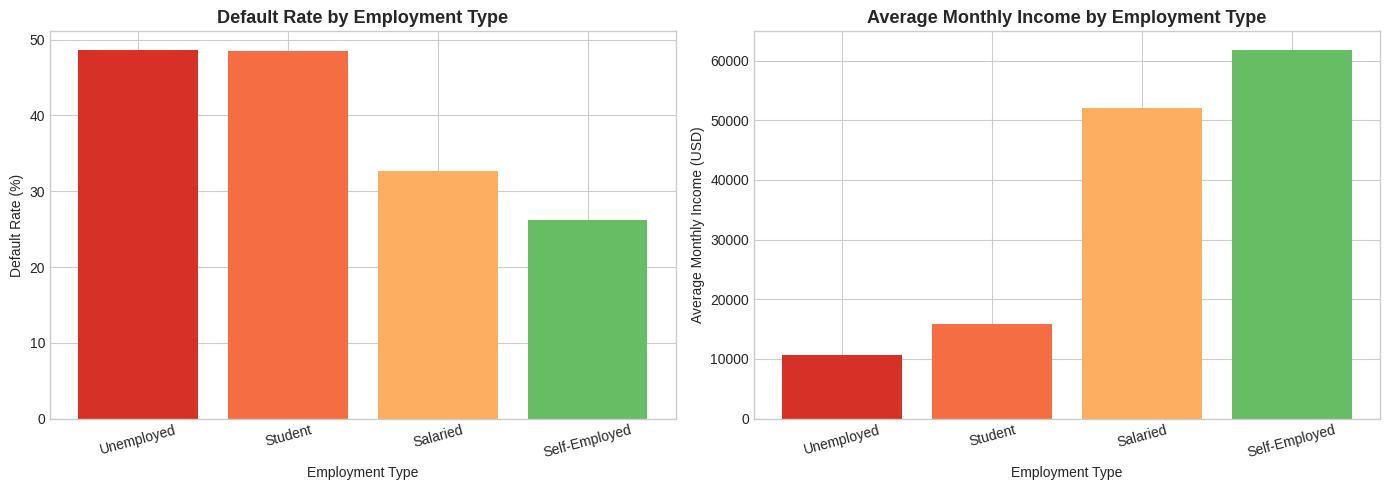

In [7]:
# Visualize Employment Default Rate

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by employment type
axes[0].bar(
    employment_defaults['employment_type'],
    employment_defaults['default_rate_pct'],
    color=['#d73027', '#f46d43', 
           '#fdae61', '#66bd63'])
axes[0].set_title(
    'Default Rate by Employment Type',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Employment Type')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

# Average income by employment type
axes[1].bar(
    employment_defaults['employment_type'],
    employment_defaults['avg_monthly_income'],
    color=['#d73027', '#f46d43', 
           '#fdae61', '#66bd63'])
axes[1].set_title(
    'Average Monthly Income by Employment Type',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Employment Type')
axes[1].set_ylabel('Average Monthly Income (USD)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### Finding 1 — Employment Type and Default Risk

Unemployed users have the highest default 
rate at 48.67%, followed closely by students 
at 48.56%. Salaried and self-employed users 
default at significantly lower rates of 
32.71% and 26.24% respectively.

The proximity of student and unemployed 
default rates is notable. Despite students 
reporting higher average income than 
unemployed users, their default rates are 
nearly identical. This suggests that income 
stability and employment security may matter 
more than income level alone.

This finding connects directly to existing 
research. The Varsity (2026) specifically 
warns that students are vulnerable BNPL 
users, and our data supports this concern 
with a 48.56% student default rate.

Income values in this dataset appear 
inconsistent with real-world expectations. 
Unemployed users report an average monthly 
income of $10,671 USD, which is 
unrealistically high. This suggests the 
synthetic data generation did not model 
income as a function of employment status. 
As a result, income will not be used as a 
primary predictor in subsequent analysis. 
Focus will shift to behavioural indicators 
such as missed payments, repayment delay 
and debt-to-income ratio.


#### Data Quality Observation

This dataset is synthetic and was designed 
for machine learning practice rather than 
to reflect real-world distributions 
precisely. Beyond the income inconsistencies 
noted in Finding 1, absolute values across 
other variables should be interpreted with 
caution.

However, the relative patterns between 
groups remain analytically meaningful. The 
direction and magnitude of differences 
across employment type, age, behavioural 
indicators and credit metrics can still 
inform meaningful risk insights even where 
absolute values are unrealistic.

This analysis will prioritise relative 
comparisons and behavioural variables over 
absolute financial values where possible.


### Age and Default Risk

Research from Payments Canada (2022) found 
that Canadians aged 18-34 are the highest 
adopters of BNPL services. We investigate 
whether younger users also carry higher 
default risk.

In [8]:
# Default Rate by Age Group

query = """
SELECT 
    CASE 
        WHEN age BETWEEN 18 AND 24 
            THEN '18-24'
        WHEN age BETWEEN 25 AND 34 
            THEN '25-34'
        WHEN age BETWEEN 35 AND 44 
            THEN '35-44'
        WHEN age BETWEEN 45 AND 59 
            THEN '45-59'
    END as age_group,
    COUNT(*) as total_users,
    SUM(default_flag) as total_defaults,
    ROUND(AVG(default_flag)*100, 2) 
        as default_rate_pct,
    ROUND(AVG(credit_score), 0) 
        as avg_credit_score
FROM bnpl_data
GROUP BY age_group
ORDER BY default_rate_pct DESC;
"""

age_defaults = pd.read_sql_query(query, conn)
age_defaults


,age_group,total_users,total_defaults,default_rate_pct,avg_credit_score
0,18-24,1716,800,46.62,394.00
1,25-34,2451,984,40.15,440.00
2,35-44,2439,946,38.79,453.00
3,45-59,3739,1310,35.04,475.00


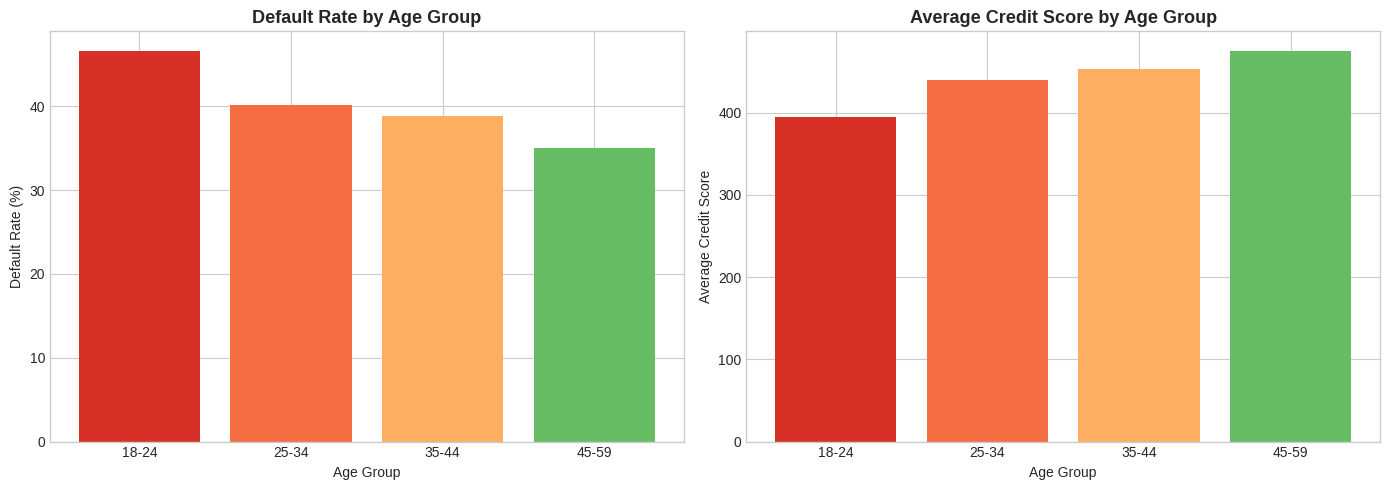

In [9]:
# Visualize Age Group Default Rate

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by age group
axes[0].bar(
    age_defaults['age_group'],
    age_defaults['default_rate_pct'],
    color=['#d73027', '#f46d43',
           '#fdae61', '#66bd63'])
axes[0].set_title(
    'Default Rate by Age Group',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Default Rate (%)')

# Average credit score by age group
axes[1].bar(
    age_defaults['age_group'],
    age_defaults['avg_credit_score'],
    color=['#d73027', '#f46d43',
           '#fdae61', '#66bd63'])
axes[1].set_title(
    'Average Credit Score by Age Group',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Credit Score')

plt.tight_layout()
plt.show()


### Finding 2 — Age and Default Risk

Younger users carry significantly higher 
default risk. Users aged 18-24 have the 
highest default rate at 46.62%, while users 
aged 45-59 have the lowest at 35.04%.

Credit score follows the same pattern. 
Users aged 18-24 have the lowest average 
credit score at 394, compared to 475 for 
users aged 45-59. This is consistent with 
expectations as younger users have had less 
time to build credit history and financial 
stability.

This finding directly supports research from 
Payments Canada (2022), which identified 
Canadians aged 18-34 as the highest adopters 
of BNPL services. Our data suggests this 
same group also carries elevated default 
risk, raising questions about whether BNPL 
products are being adopted most heavily by 
users least equipped to manage them.

Combined with Finding 1, a pattern is 
emerging. The most vulnerable BNPL users 
tend to be young, students or unemployed, 
with lower credit scores. This aligns with 
the FCAC (2021) finding that 39% of Canadian 
BNPL users adopted the service out of 
financial necessity rather than strategic 
choice.

One additional observation worth noting is 
that even the lowest risk age group (45-59) 
carries a 35.04% default rate, which remains 
exceptionally high compared to traditional 
credit products. This reinforces the 
overall data quality observation that 
absolute values in this synthetic dataset 
should be interpreted cautiously, while 
relative patterns between groups remain 
meaningful.


### Behavioural Indicators and Default Risk

Beyond demographics, we investigate whether 
behavioural patterns such as missed 
payments, repayment delays and app usage 
frequency are associated with default risk. 
Behavioural indicators may capture financial 
stress signals that demographic variables 
alone cannot reveal.


In [10]:
# Missed Payments and Default Rate

query = """
SELECT 
    missed_payments,
    COUNT(*) as total_users,
    SUM(default_flag) as total_defaults,
    ROUND(AVG(default_flag)*100, 2) 
        as default_rate_pct
FROM bnpl_data
GROUP BY missed_payments
ORDER BY missed_payments ASC;
"""

missed_defaults = pd.read_sql_query(query, conn)
missed_defaults


,missed_payments,total_users,total_defaults,default_rate_pct
0,0,3704,1027,27.73
1,1,3837,1442,37.58
2,2,1969,877,44.54
3,3,653,538,82.39
4,4,143,125,87.41
5,5,31,23,74.19
6,6,7,7,100.00
7,7,1,1,100.00


In [11]:
# Repayment Delay and Default Rate

query = """
SELECT 
    CASE 
        WHEN repayment_delay_days = 0 
            THEN 'No Delay'
        WHEN repayment_delay_days <= 7 
            THEN '1-7 Days'
        WHEN repayment_delay_days <= 14 
            THEN '8-14 Days'
        ELSE '15+ Days'
    END as delay_category,
    COUNT(*) as total_users,
    SUM(default_flag) as total_defaults,
    ROUND(AVG(default_flag)*100, 2) 
        as default_rate_pct
FROM bnpl_data
GROUP BY delay_category
ORDER BY default_rate_pct DESC;
"""

delay_defaults = pd.read_sql_query(query, conn)
delay_defaults


,delay_category,total_users,total_defaults,default_rate_pct
0,15+ Days,2385,1569,65.79
1,8-14 Days,3184,1115,35.02
2,1-7 Days,3557,1014,28.51
3,No Delay,1219,342,28.06


In [12]:
# App Usage and Default Rate

query = """
SELECT 
    CASE 
        WHEN app_usage_frequency < 2 
            THEN 'Low (under 2x/week)'
        WHEN app_usage_frequency <= 5 
            THEN 'Medium (2-5x/week)'
        ELSE 'High (5x+/week)'
    END as usage_category,
    COUNT(*) as total_users,
    SUM(default_flag) as total_defaults,
    ROUND(AVG(default_flag)*100, 2) 
        as default_rate_pct
FROM bnpl_data
GROUP BY usage_category
ORDER BY default_rate_pct DESC;
"""

usage_defaults = pd.read_sql_query(query, conn)
usage_defaults


,usage_category,total_users,total_defaults,default_rate_pct
0,Low (under 2x/week),1140,450,39.47
1,High (5x+/week),5760,2254,39.13
2,Medium (2-5x/week),3445,1336,38.78


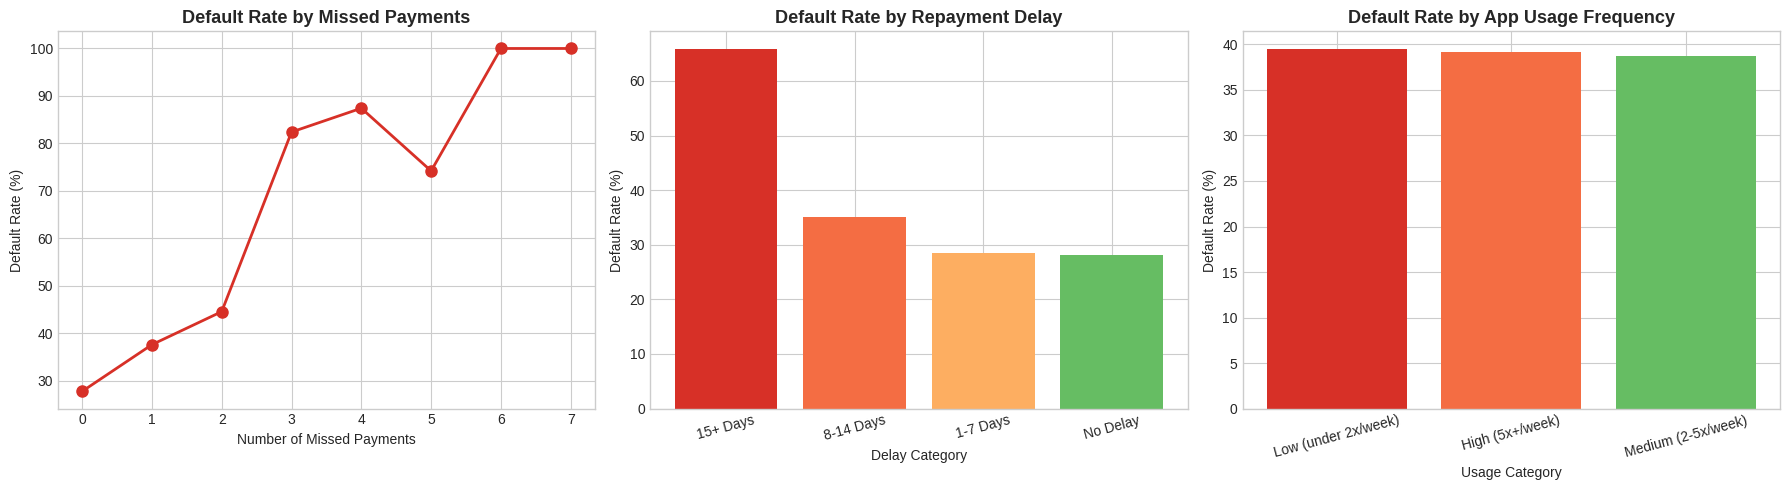

In [13]:
# Behavioural Visualizations

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Missed payments vs default rate
axes[0].plot(
    missed_defaults['missed_payments'],
    missed_defaults['default_rate_pct'],
    marker='o',
    color='#d73027',
    linewidth=2,
    markersize=8)
axes[0].set_title(
    'Default Rate by Missed Payments',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Missed Payments')
axes[0].set_ylabel('Default Rate (%)')

# Repayment delay vs default rate
axes[1].bar(
    delay_defaults['delay_category'],
    delay_defaults['default_rate_pct'],
    color=['#d73027', '#f46d43',
           '#fdae61', '#66bd63'])
axes[1].set_title(
    'Default Rate by Repayment Delay',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Delay Category')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

# App usage vs default rate
axes[2].bar(
    usage_defaults['usage_category'],
    usage_defaults['default_rate_pct'],
    color=['#d73027', '#f46d43', '#66bd63'])
axes[2].set_title(
    'Default Rate by App Usage Frequency',
    fontsize=13, fontweight='bold')
axes[2].set_xlabel('Usage Category')
axes[2].set_ylabel('Default Rate (%)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### Finding 3 — Behavioural Indicators and Default Risk

**Missed Payments**

Missed payments show the strongest and most 
consistent relationship with default risk 
in this dataset. Users with zero missed 
payments default at 27.73%, rising sharply 
to 37.58% with one missed payment, 44.54% 
with two, and 82.39% with three. Users with 
six or seven missed payments defaulted at 
100%.

This escalating pattern suggests that missed 
payments function as a leading indicator of 
default risk. Even a single missed payment 
nearly doubles the likelihood of default 
compared to users with a clean repayment 
history. For risk monitoring purposes, 
missed payment count may be one of the most 
actionable early warning signals available.

**Repayment Delay**

Repayment delay shows a similarly strong 
pattern. Users with delays of 15 or more 
days default at 65.79%, compared to 28.06% 
for users with no delay at all. Notably, 
the jump between the 8-14 day and 15+ day 
categories is substantial, suggesting that 
15 days may represent a meaningful 
threshold beyond which default risk 
escalates significantly.

**App Usage Frequency**

App usage frequency shows no meaningful 
pattern across default rates. Low, medium 
and high usage groups all default at 
approximately 39%, closely mirroring the 
overall dataset default rate of 39.05%. 

This suggests that app engagement alone is 
not a reliable predictor of default risk 
and should not be weighted heavily in risk 
scoring models. Users who engage frequently 
with the app are no more or less likely to 
default than infrequent users.

**Summary**

Behavioural indicators tell a clearer story 
than demographic variables alone. Missed 
payments and repayment delay are strongly 
associated with default risk, while app 
usage frequency adds little predictive 
value. These findings suggest that early 
intervention at the first signs of repayment 
difficulty could be a meaningful strategy 
for reducing BNPL default rates.


### Financial Indicators and Default Risk

We examine two traditional credit risk 
indicators, debt-to-income ratio (DTI) 
and credit score, to determine whether 
standard financial metrics predict BNPL 
default risk as effectively as behavioural 
indicators.


In [14]:
# DTI Ratio and Default Rate

query = """
SELECT 
    CASE 
        WHEN debt_to_income_ratio < 0.3 
            THEN 'Low DTI (under 0.3)'
        WHEN debt_to_income_ratio < 0.5 
            THEN 'Medium DTI (0.3-0.5)'
        WHEN debt_to_income_ratio < 0.7 
            THEN 'High DTI (0.5-0.7)'
        ELSE 'Very High DTI (0.7+)'
    END as dti_category,
    COUNT(*) as total_users,
    SUM(default_flag) as total_defaults,
    ROUND(AVG(default_flag)*100, 2) 
        as default_rate_pct,
    ROUND(AVG(debt_to_income_ratio), 2) 
        as avg_dti
FROM bnpl_data
GROUP BY dti_category
ORDER BY default_rate_pct DESC;
"""

dti_defaults = pd.read_sql_query(query, conn)
dti_defaults


,dti_category,total_users,total_defaults,default_rate_pct,avg_dti
0,High DTI (0.5-0.7),157,79,50.32,0.55
1,Medium DTI (0.3-0.5),1816,861,47.41,0.37
2,Low DTI (under 0.3),8368,3100,37.05,0.13
3,Very High DTI (0.7+),4,0,0.00,0.72


In [15]:
# Credit Score and Default Rate

query = """
SELECT 
    CASE 
        WHEN credit_score < 400 
            THEN 'Very Poor (under 400)'
        WHEN credit_score < 500 
            THEN 'Poor (400-499)'
        WHEN credit_score < 600 
            THEN 'Fair (500-599)'
        WHEN credit_score < 700 
            THEN 'Good (600-699)'
        ELSE 'Excellent (700+)'
    END as credit_category,
    COUNT(*) as total_users,
    SUM(default_flag) as total_defaults,
    ROUND(AVG(default_flag)*100, 2) 
        as default_rate_pct,
    ROUND(AVG(credit_score), 0) 
        as avg_credit_score
FROM bnpl_data
GROUP BY credit_category
ORDER BY default_rate_pct DESC;
"""

credit_defaults = pd.read_sql_query(query, conn)
credit_defaults


,credit_category,total_users,total_defaults,default_rate_pct,avg_credit_score
0,Very Poor (under 400),5101,2529,49.58,335.00
1,Poor (400-499),1780,880,49.44,446.00
2,Fair (500-599),1721,515,29.92,548.00
3,Good (600-699),1160,81,6.98,644.00
4,Excellent (700+),583,35,6.00,759.00


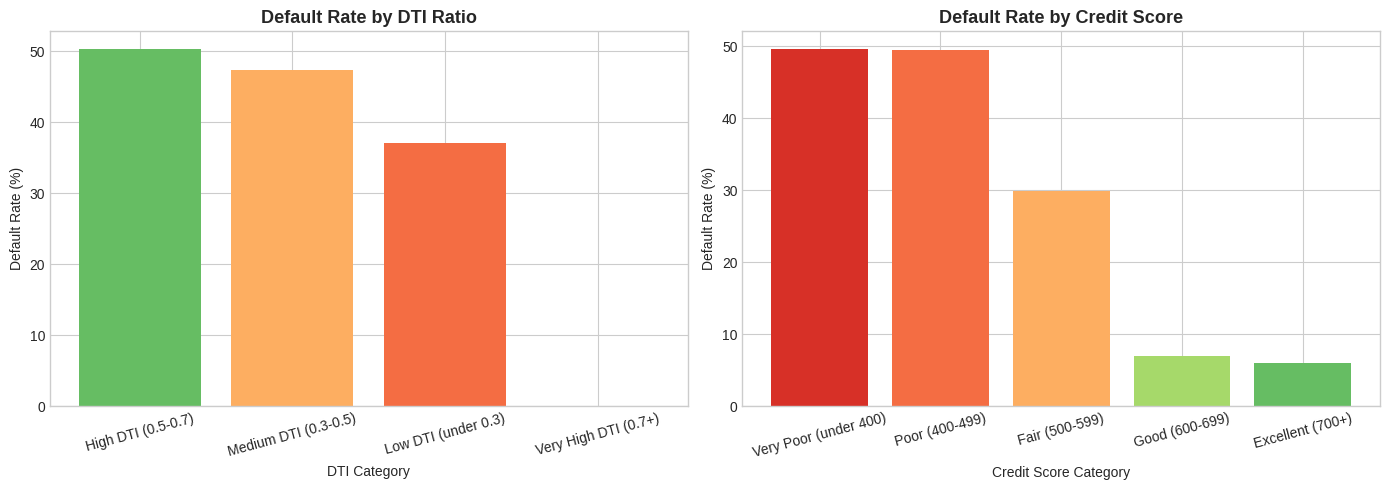

In [16]:
# Financial Indicator Visualizations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DTI ratio vs default rate
axes[0].bar(
    dti_defaults['dti_category'],
    dti_defaults['default_rate_pct'],
    color=['#66bd63', '#fdae61',
           '#f46d43', '#d73027'])
axes[0].set_title(
    'Default Rate by DTI Ratio',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('DTI Category')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

# Credit score vs default rate
axes[1].bar(
    credit_defaults['credit_category'],
    credit_defaults['default_rate_pct'],
    color=['#d73027', '#f46d43',
           '#fdae61', '#a6d96a',
           '#66bd63'])
axes[1].set_title(
    'Default Rate by Credit Score',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Credit Score Category')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### Finding 4 — Financial Indicators and Default Risk

**Credit Score**

Credit score emerges as one of the strongest 
predictors of default risk in this dataset. 
Users with very poor credit scores (under 
400) default at 49.58%, nearly identical to 
users with poor scores (400-499) at 49.44%. 
Default risk drops substantially for users 
with fair credit (500-599) at 29.92%, and 
falls dramatically for good (6.98%) and 
excellent (6.00%) credit score holders.

The sharp decline between poor and fair 
credit categories suggests that a credit 
score of 500 may represent a meaningful 
risk threshold for BNPL providers.

**Debt-to-Income Ratio**

Higher DTI ratios are generally associated 
with higher default rates, though the 
pattern is less consistent than credit 
score. Medium DTI users (0.3-0.5) default 
at 47.41% compared to 37.05% for low DTI 
users (under 0.3). 

The Very High DTI category (0.7+) contains 
only 4 users and 0 defaults, which is 
insufficient for meaningful analysis and 
should be interpreted with caution.

**The Relationship Between Missed Payments 
and Credit Score**

An important connection emerges between 
Finding 3 and Finding 4. Missed payments 
directly impact credit scores over time, 
meaning these two variables are not 
independent. Users who miss payments 
accumulate lower credit scores, which in 
turn predicts higher default risk.

This suggests that missed payments function 
as a leading behavioural indicator of 
default, while credit score captures the 
accumulated financial history of that 
behaviour. For early risk detection, 
monitoring missed payments in real time 
may be more actionable than credit score 
alone, as it signals emerging risk before 
it is fully reflected in a credit score.

This finding has direct implications for 
BNPL risk management. Traditional credit 
scoring may underestimate risk for new or 
young borrowers who have limited credit 
history, while behavioural monitoring of 
payment patterns could provide earlier and 
more accurate risk signals.


## High Risk Customer Profile

Drawing on findings from previous analysis, 
we construct a profile of the highest risk 
BNPL user by examining the characteristics 
most strongly associated with default.


In [17]:
# High Risk Customer Profile

query = """
SELECT 
    employment_type,
    CASE 
        WHEN age BETWEEN 18 AND 24 
            THEN '18-24'
        WHEN age BETWEEN 25 AND 34 
            THEN '25-34'
        WHEN age BETWEEN 35 AND 44 
            THEN '35-44'
        ELSE '45-59'
    END as age_group,
    ROUND(AVG(credit_score), 0) 
        as avg_credit_score,
    ROUND(AVG(missed_payments), 2) 
        as avg_missed_payments,
    ROUND(AVG(repayment_delay_days), 2) 
        as avg_repayment_delay,
    ROUND(AVG(debt_to_income_ratio), 2) 
        as avg_dti,
    COUNT(*) as total_users,
    ROUND(AVG(default_flag)*100, 2) 
        as default_rate_pct
FROM bnpl_data
WHERE default_flag = 1
GROUP BY employment_type, age_group
ORDER BY default_rate_pct DESC
LIMIT 10;
"""

high_risk_profile = pd.read_sql_query(
    query, conn)
high_risk_profile


,employment_type,age_group,avg_credit_score,avg_missed_payments,avg_repayment_delay,avg_dti,total_users,default_rate_pct
0,Salaried,18-24,434.00,1.35,11.53,0.14,209,100.00
1,Salaried,25-34,472.00,1.60,12.42,0.11,226,100.00
2,Salaried,35-44,483.00,1.50,12.24,0.11,199,100.00
3,Salaried,45-59,498.00,1.53,12.52,0.11,227,100.00
4,Self-Employed,18-24,450.00,1.40,11.66,0.13,182,100.00
5,Self-Employed,25-34,489.00,1.56,12.03,0.11,154,100.00
6,Self-Employed,35-44,511.00,1.67,13.75,0.10,130,100.00
7,Self-Employed,45-59,530.00,1.70,13.71,0.09,203,100.00
8,Student,18-24,329.00,1.25,9.64,0.29,193,100.00
9,Student,25-34,344.00,1.26,10.44,0.26,287,100.00


In [18]:
# Compare Defaulted vs Non-Defaulted Users

query = """
SELECT 
    CASE 
        WHEN default_flag = 1 
            THEN 'Defaulted'
        ELSE 'Paid on Time'
    END as user_type,
    ROUND(AVG(age), 0) as avg_age,
    ROUND(AVG(credit_score), 0) 
        as avg_credit_score,
    ROUND(AVG(missed_payments), 2) 
        as avg_missed_payments,
    ROUND(AVG(repayment_delay_days), 2) 
        as avg_repayment_delay,
    ROUND(AVG(debt_to_income_ratio), 2) 
        as avg_dti,
    ROUND(AVG(purchase_amount), 2) 
        as avg_purchase_amount,
    COUNT(*) as total_users
FROM bnpl_data
GROUP BY default_flag;
"""

comparison = pd.read_sql_query(query, conn)
comparison


,user_type,avg_age,avg_credit_score,avg_missed_payments,avg_repayment_delay,avg_dti,avg_purchase_amount,total_users
0,Paid on Time,39.00,484.00,0.80,7.21,0.16,4097.03,6305
1,Defaulted,37.00,393.00,1.35,11.14,0.21,3795.83,4040


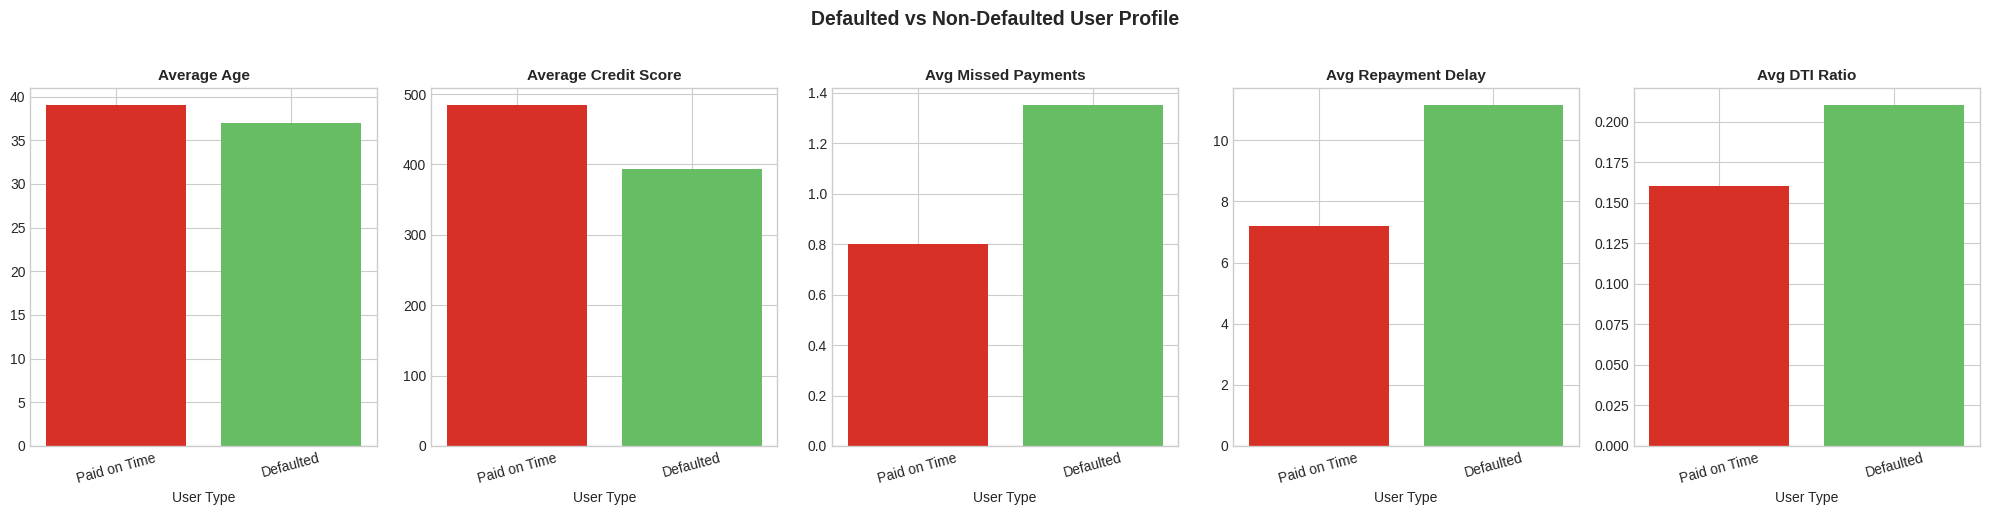

In [19]:
# High vs Low Risk Comparison

metrics = ['avg_age', 'avg_credit_score', 
           'avg_missed_payments',
           'avg_repayment_delay', 'avg_dti']

labels = ['Average Age', 'Average Credit Score',
          'Avg Missed Payments', 
          'Avg Repayment Delay',
          'Avg DTI Ratio']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (metric, label) in enumerate(
        zip(metrics, labels)):
    axes[i].bar(
        comparison['user_type'],
        comparison[metric],
        color=['#d73027', '#66bd63'])
    axes[i].set_title(
        label,
        fontsize=11, fontweight='bold')
    axes[i].set_xlabel('User Type')
    axes[i].tick_params(
        axis='x', rotation=15)

plt.suptitle(
    'Defaulted vs Non-Defaulted User Profile',
    fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### High Risk Customer Profile

**Comparison of Defaulted vs Non-Defaulted 
Users**

Comparing defaulted and non-defaulted users 
reveals clear differences across key risk 
indicators:

- Average credit score: 393 (defaulted) 
  vs 484 (paid on time)
- Average missed payments: 1.35 (defaulted) 
  vs 0.80 (paid on time)
- Average repayment delay: 11.14 days 
  (defaulted) vs 7.21 days (paid on time)
- Average DTI ratio: 0.21 (defaulted) 
  vs 0.16 (paid on time)
- Average purchase amount: \\$3,795
(defaulted) vs \$4,097 (paid on time)

Missed payments show the most meaningful 
difference between groups, reinforcing 
Finding 3 that payment behaviour is a 
strong leading indicator of default risk.

Interestingly, defaulted users have a 
slightly lower average purchase amount than 
non-defaulted users. This challenges the 
assumption that larger purchases drive 
default risk. It suggests that 
vulnerability lies in the user's financial 
situation rather than the size of the 
purchase itself.

**High Risk Customer Profile**

Students aged 18-34 emerge as the highest 
risk segment, with the lowest average 
credit scores (329-344) and the highest 
DTI ratios (0.26-0.29) among all groups. 
This is consistent with findings from 
The Varsity (2026), which specifically 
warned that students are vulnerable to 
BNPL financial risk.

The data quality observation from Finding 
1 is relevant here. All segments in the 
high risk profile table show a 100% default 
rate, which reflects the query filtering 
for defaulted users only rather than 
representing true segment default rates. 
True default rates by segment were 
established in Findings 1 and 2.

**Composite High Risk Profile**

Based on all findings, the highest risk 
BNPL user profile is:

- Age: 18-24
- Employment: Student or Unemployed
- Credit score: Under 400
- Missed payments: 2 or more
- Repayment delay: 15 or more days
- DTI ratio: Above 0.25

This profile represents a user who is 
likely adopting BNPL out of financial 
necessity rather than strategic choice, 
consistent with FCAC (2021) findings that 
39% of Canadian BNPL users could not 
afford the full purchase upfront.


## Conclusions

This analysis investigated what distinguishes 
customers who successfully leverage BNPL 
from those who default, exploring whether 
BNPL fulfils its promise of financial 
empowerment or disproportionately burdens 
vulnerable users.

### Key Findings Summary

| Finding | Key Insight |
|---|---|
| Employment Type | Unemployed and student users default at nearly 49%, compared to 26% for self-employed users |
| Age | Younger users (18-24) carry the highest default risk at 46.62% |
| Missed Payments | Single strongest predictor, escalating from 27.73% to 100% default rate |
| Repayment Delay | Users with 15+ day delays default at 65.79% vs 28.06% for no delay |
| Credit Score | Users under 500 default at approximately 50%, dropping sharply above 600 |
| App Usage | No meaningful relationship with default risk |
| High Risk Profile | Students aged 18-34 with low credit scores and multiple missed payments |

---

### Answering the Research Question

BNPL does not deliver equally on its promise 
of financial empowerment across all user 
segments. The product appears to work well 
for financially stable users with higher 
credit scores, stable employment and clean 
payment histories. For these users, BNPL 
genuinely provides flexible purchasing 
power without significant default risk.

However, the data tells a different story 
for vulnerable users. Students, unemployed 
users and young adults aged 18-24 carry 
default rates approaching 50%. These are 
precisely the users most likely to adopt 
BNPL out of financial necessity rather than 
strategic choice, as evidenced by FCAC 
(2021) findings that 39% of Canadian BNPL 
users could not afford the full purchase 
upfront.

Furthermore, the FCAC study found that 15% 
of users who repaid on time still made 
unfavourable financial trade-offs. This 
suggests the true burden of BNPL on 
vulnerable users extends beyond what 
default rates alone can capture.

The answer to the research question is 
therefore nuanced. BNPL empowers informed, 
financially stable users. For vulnerable 
users, particularly students and young 
adults with limited credit history and 
unstable income, it carries meaningful 
risk of becoming a financial burden.

---

## Recommendations

### For BNPL Providers and Financial Institutions

**1. Implement Behavioural Early Warning 
Systems**

Missed payments are the strongest and most 
actionable predictor of default risk. A 
monitoring system that flags users after 
their first missed payment could enable 
early intervention before default occurs. 
Given the sharp escalation in default risk 
from one to two missed payments, early 
outreach at the first sign of repayment 
difficulty could meaningfully reduce 
default rates.

**2. Apply Risk-Based Eligibility 
Thresholds**

Credit scores below 500 are associated with 
approximately 50% default rates. Applying 
stricter eligibility criteria or lower 
credit limits for users in this range could 
reduce portfolio default risk while still 
providing access to lower-risk users.

**3. Develop Student and Young Adult 
Specific Safeguards**

Students and users aged 18-24 represent 
the highest risk segments. Product design 
considerations such as lower initial credit 
limits, mandatory financial literacy 
prompts, or automatic payment reminders 
could reduce default risk for these 
segments specifically.

**4. Reconsider Marketing to Vulnerable 
Segments**

The FCAC (2021) finding that 39% of users 
adopted BNPL because they could not afford 
the full purchase upfront raises ethical 
questions about marketing BNPL to 
financially vulnerable users. Financial 
institutions have a responsibility to 
ensure products are appropriate for the 
users they target.

**5. Supplement Credit Scores with 
Behavioural Monitoring**

Traditional credit scores may 
underestimate risk for young borrowers 
with limited credit history. Incorporating 
real-time behavioural signals such as 
missed payment frequency and repayment 
delay patterns into risk scoring models 
could improve default prediction accuracy 
for this growing segment.

---

## Limitations

**1. Synthetic Dataset**

This analysis uses a synthetic dataset 
designed for machine learning practice. 
Income values were found to be 
inconsistent with real-world expectations, 
and absolute values across variables should 
be interpreted cautiously. Findings 
reflect relative patterns rather than 
real-world magnitudes.

**2. Elevated Default Rate**

The overall default rate of 39.05% is 
significantly higher than real-world BNPL 
default rates, which typically range from 
1-5%. This limits the generalisability of 
findings to real-world contexts.

**3. No Temporal Analysis**

This analysis treats all transactions as 
static observations. A longitudinal 
analysis tracking individual users over 
time could reveal more nuanced patterns 
in how default risk evolves.

**4. Limited Canadian Data**

While the dataset includes Canadian 
transactions, it was not possible to 
isolate Canadian-specific patterns 
meaningfully given sample size constraints. 
A Canada-specific analysis would be more 
directly relevant to the Canadian 
regulatory context.

**5. Correlation Not Causation**

All findings reflect associations between 
variables and default risk. Causal 
relationships cannot be established from 
this observational dataset alone.

---

## Future Work

- Apply logistic regression or GLM to 
  quantify the relative contribution of 
  each predictor to default risk
- Build a credit scorecard using WOE 
  binning and information value
- Incorporate survival analysis to model 
  time-to-default patterns
- Analyse Canadian transactions 
  specifically using a larger dataset
- Investigate whether BNPL default risk 
  varies by product category purchased

---

## References

1. Financial Consumer Agency of Canada. 
(2021). Pilot study: Buy now, pay later 
services in Canada. Government of Canada. 
https://www.canada.ca/en/financial-consumer-
agency/programs/research/pilot-study-buy-
now-pay-later-services-in-canada.html

2. Payments Canada. (2022). Young Canadians 
driving adoption of buy now, pay later 
services. https://www.payments.ca/insights/
research/young-canadians-driving-adoption-
buy-now-pay-later-bnpl-services

3. The Varsity. (2026). Is buy now pay later 
a trap for students? 
https://thevarsity.ca/2026/01/05/
is-buy-now-pay-later-a-trap-for-students/

4. CTV News. (2026). What to know before 
using buy now pay later apps. 
https://www.ctvnews.ca/canada/article/
what-to-know-before-using-buy-now-pay-
later-apps/
